# celldetect


In [1]:
#source /export/CIAOT/ciaot_install/20180306/ciao-4.10/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


## Getting started

In [2]:
/bin/rm -rf 578,1522
download_chandra_obsid 578,1522 evt2,flt,msk,pbk,fov,bpix,asol,pbk


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       10 Mb  ####################          < 1 s  36656.9 kb/s
  bpix     fits       19 Kb    already downloaded
  fov      fits        6 Kb    already downloaded
  asol     fits        5 Mb    already downloaded
  flt      fits        7 Kb    already downloaded
  msk      fits        5 Kb    already downloaded
  pbk      fits        4 Kb    already downloaded

      Total download size for ObsId 578 = 10 Mb
      Total download time for ObsId 578 = < 1 s


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       20 Mb    already downloaded
  bpix     fits       44 Kb    already downloaded
  fov      fits        6 Kb    already downloaded
  asol     fits       10 Mb    already downloaded
  flt    

In [3]:
gunzip -f 578/primary/*evt2.fits.gz
r4_header_update 578/primary/*evt2.fits

Missing keywords 'OCLKPAIR,ORC_MODE,SUM_2X2,FEP_CCD' from event file '578/primary/acisf00578N003_evt2.fits' header.
Missing keywords 'DY_AVG,DZ_AVG,DTH_AVG' from event file '578/primary/acisf00578N003_evt2.fits' header.


In [4]:
dmkeypar 578/primary/acisf00578N003_evt2.fits FEP_CCD echo+

752386


In [5]:
fluximage "578/primary/acisf00578N003_evt2.fits[ccd_id=7,sky=region(578/primary/acisf00578_000N003_fov1.fits[ccd_id=7])]"\
                binsize=1 bands=broad outroot=s3 clob+

Running fluximage
Version: 28 November 2018

Using CSC ACIS broad science energy band.
Aspect solution 578/primary/pcadf052378346N003_asol1.fits found.
Bad-pixel file 578/primary/acisf00578_000N003_bpix1.fits.gz found.
Mask file 578/secondary/acisf00578_000N003_msk1.fits found.

The output images will have 1390 by 1389 pixels, pixel size of 0.492 arcsec,
    and cover x=3506.5:4896.5:1,y=3676.5:5065.5:1.

Running tasks in parallel with 4 processors.
Creating aspect histogram for obsid 578
Creating instrument map for obsid 578
Creating exposure map for obsid 578
Thresholding data for obsid 578
Exposure-correcting image for obsid 578

The following files were created:

 The clipped counts image is:
     s3_broad_thresh.img

 The clipped exposure map is:
     s3_broad_thresh.expmap

 The exposure-corrected image is:
     s3_broad_flux.img



## Run celldetect

### Simple exmample, no expmap

In [6]:
mkpsfmap s3_broad_thresh.img s3_broad.psfmap energy=1.4967 ecf=0.8 clob+

In [7]:
punlearn celldetect
pset celldetect infile=s3_broad_thresh.img
pset celldetect outfile=s3_src.fits
pset celldetect regfile=s3_src.reg
pset celldetect psffile=s3_broad.psfmap 
celldetect mode=h clob+

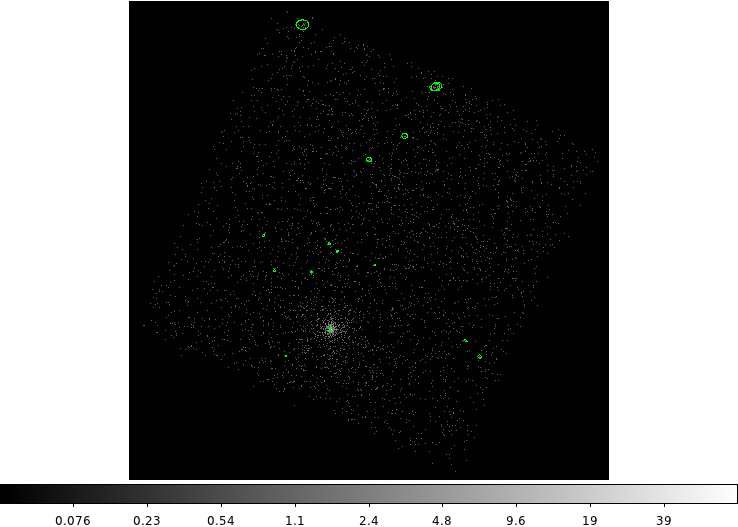

In [8]:
ds9 s3_broad_thresh.img -region s3_src.fits -log -zoom to fit -saveimage png cell1.png  -quit

display < cell1.png

### With expmap

In [9]:
punlearn celldetect
pset celldetect infile=s3_broad_thresh.img
pset celldetect outfile=s3_expmap_src.fits
pset celldetect regfile=s3_expmap_src.reg
pset celldetect expstk=s3_broad_thresh.expmap
pset celldetect expratio=0.9
pset celldetect psffile=s3_broad.psfmap 
celldetect mode=h clob+

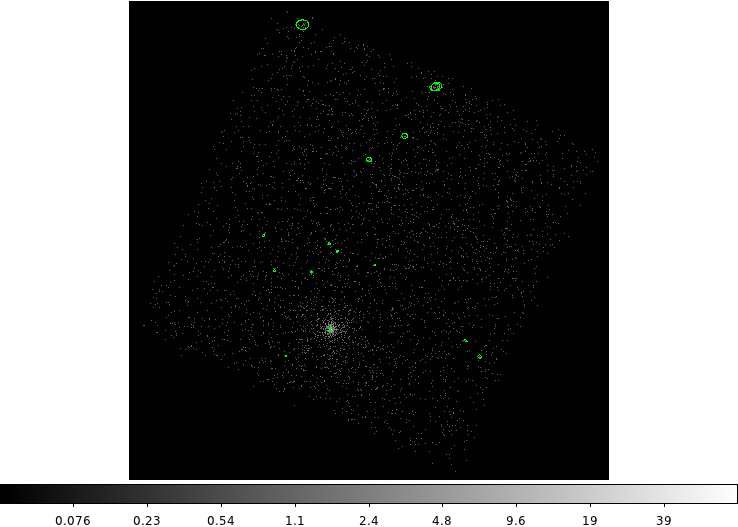

In [10]:
ds9 s3_broad_thresh.img -region s3_expmap_src.fits -log -zoom to fit -saveimage png cell2.png  -quit

display < cell2.png

## Recursive Blocking


In [11]:
dmkeypar 1522/primary/acisf01522N004_evt2.fits DETNAM echo+

ACIS-012367


In [12]:
punlearn celldetect
pset celldetect infile="1522/primary/acisf01522N004_evt2.fits[ccd_id=0:3,energy=500:7000]"
pset celldetect outfile=acisi_block_src.fits
pset celldetect regfile=acisi_block_src.reg
pset celldetect fixedcell=12
celldetect mode=h clob+ maxlogical=2048

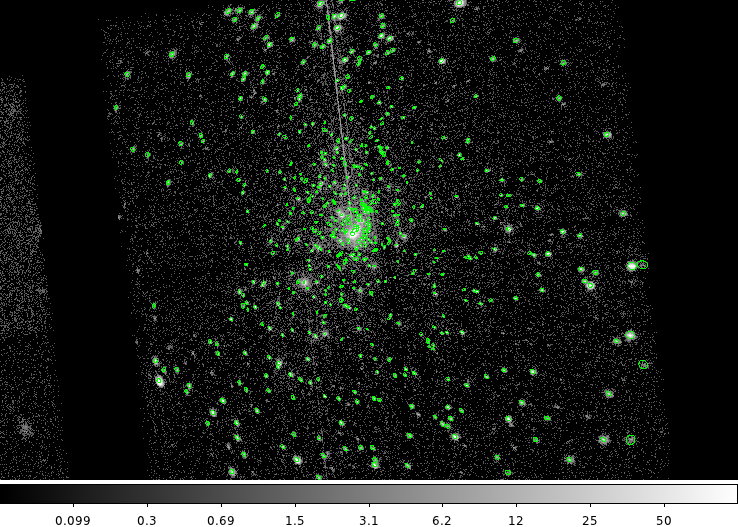

In [13]:
ds9 1522/primary/acisf01522N004_evt2.fits.gz"[events,energy=500:7000]" -log \
  -region acisi_block_src.fits -bin factor 4 -scale limits 0 100 \
  -saveimage png cell3.png  -quit

display < cell3.png

In [14]:
dmlist "acisi_block_src.fits[block=1]" counts

576     


In [15]:
dmlist "acisi_block_src.fits[block=2]" counts

8       


In [16]:
dmlist "acisi_block_src.fits[block=4]" counts

0       


## With exposure maps

In [17]:
echo 4096.5 - 1024 | bc -l
echo 4096.5 + 1024 | bc -l

3072.5
5120.5


In [18]:
fluximage 1522/primary/*evt2.fits.gz"[ccd_id=0:3]" \
  out=bin1 xygrid=3072.5:5120.5:1,3072.5:5120.5:1 mode=h clob+ band=broad

Running fluximage
Version: 28 November 2018

Using event file 1522/primary/acisf01522N004_evt2.fits.gz[ccd_id=0:3]
Using CSC ACIS broad science energy band.
Aspect solution 1522/primary/pcadf070998448N004_asol1.fits found.
Bad-pixel file 1522/primary/acisf01522_002N004_bpix1.fits.gz found.
Mask file 1522/secondary/acisf01522_002N004_msk1.fits found.

The output images will have 2048 by 2048 pixels,
    and cover x=3072.5:5120.5:1,y=3072.5:5120.5:1.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 1522
Creating 4 instrument maps for obsid 1522
Creating 4 exposure maps for obsid 1522
Combining 4 exposure maps for obsid 1522
Thresholding data for obsid 1522
Exposure-correcting image for obsid 1522

The following files were created:

 The clipped counts image is:
     bin1_broad_thresh.img

 The clipped exposure map is:
     bin1_broad_thresh.expmap

 The exposure-corrected image is:
     bin1_broad_flux.img



In [19]:
echo 4096.5 - 2048 | bc -l
echo 4096.5 + 2048 | bc -l

2048.5
6144.5


In [20]:
fluximage 1522/primary/*evt2.fits.gz"[ccd_id=0:3]" \
  out=bin2 xygrid=2048.5:6144.5:2,2048.5:6144.5:2 mode=h clob+ band=broad

Running fluximage
Version: 28 November 2018

Using event file 1522/primary/acisf01522N004_evt2.fits.gz[ccd_id=0:3]
Using CSC ACIS broad science energy band.
Aspect solution 1522/primary/pcadf070998448N004_asol1.fits found.
Bad-pixel file 1522/primary/acisf01522_002N004_bpix1.fits.gz found.
Mask file 1522/secondary/acisf01522_002N004_msk1.fits found.

The output images will have 2048 by 2048 pixels,
    and cover x=2048.5:6144.5:2,y=2048.5:6144.5:2.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 1522
Creating 4 instrument maps for obsid 1522
Creating 4 exposure maps for obsid 1522
Combining 4 exposure maps for obsid 1522
Thresholding data for obsid 1522
Exposure-correcting image for obsid 1522

The following files were created:

 The clipped counts image is:
     bin2_broad_thresh.img

 The clipped exposure map is:
     bin2_broad_thresh.expmap

 The exposure-corrected image is:
     bin2_broad_flux.img



In [21]:
fluximage 1522/primary/*evt2.fits.gz"[ccd_id=0:3]" \
  out=bin4 xygrid=0.5:8192.5:4,0.5:8192.5:4 mode=h clob+ band=broad

Running fluximage
Version: 28 November 2018

Using event file 1522/primary/acisf01522N004_evt2.fits.gz[ccd_id=0:3]
Using CSC ACIS broad science energy band.
Aspect solution 1522/primary/pcadf070998448N004_asol1.fits found.
Bad-pixel file 1522/primary/acisf01522_002N004_bpix1.fits.gz found.
Mask file 1522/secondary/acisf01522_002N004_msk1.fits found.

The output images will have 2048 by 2048 pixels,
    and cover x=0.5:8192.5:4,y=0.5:8192.5:4.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 1522
Creating 4 instrument maps for obsid 1522
Creating 4 exposure maps for obsid 1522
Combining 4 exposure maps for obsid 1522
Thresholding data for obsid 1522
Exposure-correcting image for obsid 1522

The following files were created:

 The clipped counts image is:
     bin4_broad_thresh.img

 The clipped exposure map is:
     bin4_broad_thresh.expmap

 The exposure-corrected image is:
     bin4_broad_flux.img



In [22]:
/bin/ls bin?_broad_thresh.expmap | sort > expmap.lis
cat expmap.lis

bin1_broad_thresh.expmap
bin2_broad_thresh.expmap
bin4_broad_thresh.expmap


In [23]:
mkpsfmap bin1_broad_thresh.expmap bin1_broad.psfmap energy=1.4967 ecf=0.8 clob+
mkpsfmap bin2_broad_thresh.expmap bin2_broad.psfmap energy=1.4967 ecf=0.8 clob+
mkpsfmap bin4_broad_thresh.expmap bin4_broad.psfmap energy=1.4967 ecf=0.8 clob+

In [24]:
/bin/ls bin?_broad.psfmap | sort > psf.lis
cat psf.lis

bin1_broad.psfmap
bin2_broad.psfmap
bin4_broad.psfmap


In [25]:
punlearn celldetect
pset celldetect infile="1522/primary/acisf01522N004_evt2.fits[ccd_id=0:3,energy=500:7000]"
pset celldetect outfile=acisi_block_expmap_src.fits
pset celldetect regfile=acisi_block_expmap_src.reg
pset celldetect psffile=@psf.lis
pset celldetect expstk=@expmap.lis
pset celldetect expratio=0.99
celldetect mode=h clob+ maxlogical=2048

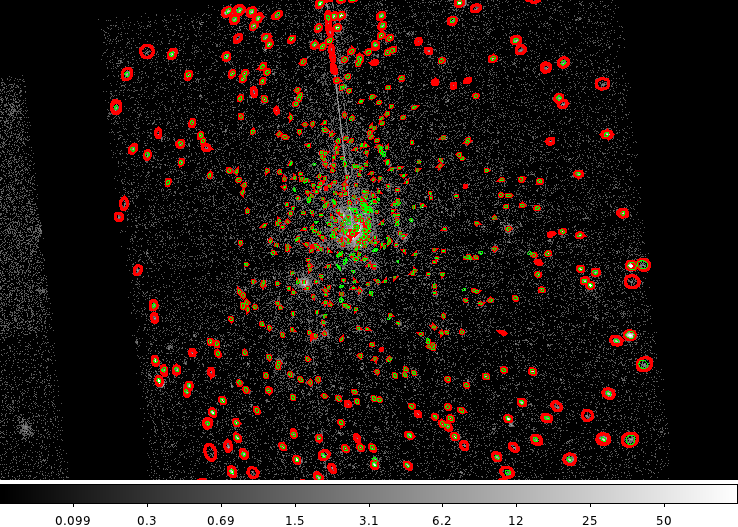

In [26]:
ds9 1522/primary/acisf01522N004_evt2.fits.gz"[events,energy=500:7000]" -log \
  -region acisi_block_src.fits \
  -region color red -region width 3 -region acisi_block_expmap_src.fits \
  -bin factor 4 -scale limits 0 100 -saveimage png cell4.png  -quit

display < cell4.png

# Cleanup

In [27]:
/bin/rm -rf 1522 578
/bin/rm -f bin*.img bin*.expmap bin*.psfmap
/bin/rm -f s3*img s3*.expmap s3*.psfmap
/bin/rm -rf param